# 🏦 Neobank Analytics: Exploratory Data Analysis (EDA) & SQL Modeling
### An end-to-end Data Science & Business Intelligence analysis of cross-border transactional data.

**Author:** Nico Carello  
**Repository:** [github.com/Nicocarello/neobank-data-ai](https://github.com/Nicocarello/neobank-data-ai)  
**Live BI Dashboard:** [Looker Studio Report](https://datastudio.google.com/reporting/896e4bb8-b2d6-4fd4-8398-96cfa992f738/page/9TmAG)

---

## 🎯 Executive Overview
This notebook presents an end-to-end Exploratory Data Analysis (EDA), unit economics audit, and SQL validation for a **Global Neobank** operating in Latin America (Argentina, Chile, Colombia, Mexico, Peru).

### Core Analysis Objectives:
1. **Multicurrency Normalization & Data Integrity:** Resolving heterogeneous local currency distortions (ARS, CLP, COP, MXN, PEN) by evaluating standard USD aggregates.
2. **Monetization & Take Rate Dynamics:** Assessing Gross Revenue ($1,282,364.89 USD) and consolidated monetization rates across 4 product lines.
3. **Cross-Border Corridor Flows:** Analyzing regional money movement patterns and trade routes.
4. **Customer Behavior & Activation:** Identifying active transacting users, top revenue drivers, and inactive accounts.
5. **Relational SQL Validation:** Executing optimized ANSI SQL queries with Window Functions and CTEs directly against SQLite (`neobank.db`).


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Database connection to audited SQLite replica
conn = sqlite3.connect('neobank.db')
print("Successfully connected to neobank.db (SQLite)")


Successfully connected to neobank.db (SQLite)


In [2]:
# Load relational tables
df_customers = pd.read_sql('SELECT * FROM customer', conn)
df_transactions = pd.read_sql('SELECT * FROM "transaction"', conn)

# Inspect shapes and timestamps
df_transactions['transaction_datetime'] = pd.to_datetime(df_transactions['transaction_datetime'])
df_customers['created_at'] = pd.to_datetime(df_customers['created_at'])

print(f"Customers dataset: {df_customers.shape[0]} rows, {df_customers.shape[1]} columns")
print(f"Transactions dataset: {df_transactions.shape[0]} rows, {df_transactions.shape[1]} columns")
print(f"Date range: {df_transactions['transaction_datetime'].min().date()} to {df_transactions['transaction_datetime'].max().date()}")


Customers dataset: 1000 rows, 7 columns
Transactions dataset: 5000 rows, 17 columns
Date range: 2024-01-02 to 2025-01-22


In [3]:
# Preview top 5 transactional records
df_transactions[['transaction_id', 'customer_id', 'product', 'origin_country', 'destiny_country', 'origin_amount_usd', 'revenue', 'transaction_datetime']].head()


transaction_id,customer_id,product,origin_country,destiny_country,origin_amount_usd,revenue,transaction_datetime
1,967,Tarjeta,México,Chile,2488.09,463.67,2024-12-29 06:55:30
2,457,P2P,Colombia,México,1986.93,485.15,2024-12-26 15:58:52
3,643,Remesa,Perú,México,4373.58,342.44,2024-11-25 06:54:50
4,189,Tarjeta,Argentina,Argentina,1060.45,154.75,2024-05-08 16:52:52
5,844,Exchange,Chile,Colombia,2254.88,143.97,2024-02-03 11:28:54


---
## 🪙 1. The Multi-Currency Challenge & Unit Economics

In multi-country fintech operations, customers initiate transactions in their local currencies (**ARS, CLP, COP, MXN, PEN**). 
Summing nominal amounts across different currencies generates arithmetic distortions due to varying exchange rates (e.g. 1 USD is ~1,000 ARS, ~950 CLP, but ~20 MXN).

### Fintech Principles:
- **Rule #1:** For global volume, aggregate `origin_amount_usd`.
- **Rule #2:** Gross Revenue is represented by the audited `revenue` column in USD.
- **Rule #3:** Take Rate (%) is calculated as:
$$\text{Take Rate (\%)} = \frac{\sum \text{Revenue (USD)}}{\sum \text{Origin Amount USD}} \times 100$$


In [4]:
# Compute Global Fintech KPIs
total_volume_usd = df_transactions['origin_amount_usd'].sum()
total_revenue_usd = df_transactions['revenue'].sum()
take_rate_pct = (total_revenue_usd / total_volume_usd) * 100
avg_ticket_usd = df_transactions['origin_amount_usd'].mean()
total_txns = len(df_transactions)
active_customers = df_transactions['customer_id'].nunique()

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Processed Volume (USD)',
        'Total Gross Revenue (USD)',
        'Consolidated Take Rate (%)',
        'Average Ticket (USD)',
        'Total Transactions Audited',
        'Active Transacting Customers'
    ],
    'Value': [
        f"${total_volume_usd:,.2f}",
        f"${total_revenue_usd:,.2f}",
        f"{take_rate_pct:.2f}%",
        f"${avg_ticket_usd:,.2f}",
        f"{total_txns:,}",
        f"{active_customers:,}"
    ]
})

kpi_summary


Metric,Value
Total Processed Volume (USD),"$12,650,673.69"
Total Gross Revenue (USD),"$1,282,364.89"
Consolidated Take Rate (%),10.14%
Average Ticket (USD),"$2,530.13"
Total Transactions Audited,"5,000"
Active Transacting Customers,989


---
## 📈 2. Monthly Dynamics & Seasonality (2024 - 2025)

Let's evaluate the scaling trajectory month-over-month. We examine whether volume growth is correlated with margin expansion or compression.


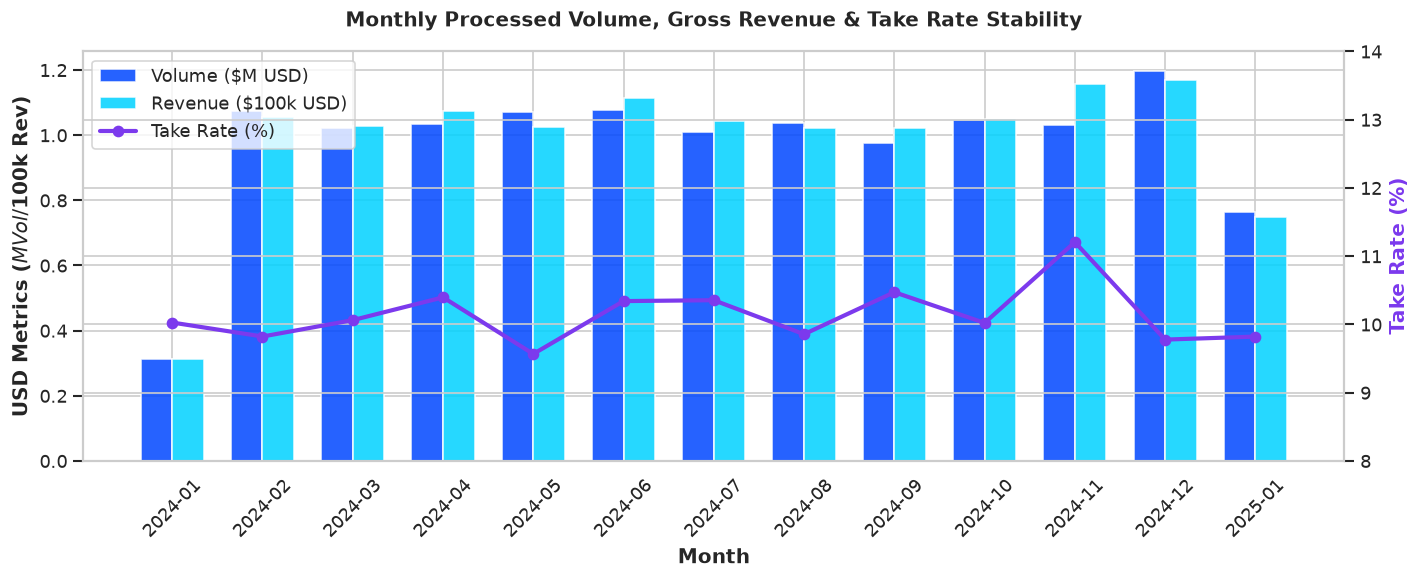

In [5]:
# Monthly aggregation
df_transactions['month'] = df_transactions['transaction_datetime'].dt.strftime('%Y-%m')
monthly_perf = df_transactions.groupby('month').agg(
    total_txns=('transaction_id', 'count'),
    volume_usd=('origin_amount_usd', 'sum'),
    revenue_usd=('revenue', 'sum')
).reset_index()
monthly_perf['take_rate_pct'] = (monthly_perf['revenue_usd'] / monthly_perf['volume_usd']) * 100

# Dual-axis visualization
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
x = np.arange(len(monthly_perf))
w = 0.35

ax1.bar(x - w/2, monthly_perf['volume_usd'] / 1e6, width=w, label='Volume ($M USD)', color='#0047FF', alpha=0.85)
ax1.bar(x + w/2, monthly_perf['revenue_usd'] / 1e5, width=w, label='Revenue ($100k USD)', color='#00D2FF', alpha=0.85)
ax2.plot(x, monthly_perf['take_rate_pct'], color='#7C3AED', marker='o', linewidth=2.5, label='Take Rate (%)')

ax1.set_xlabel('Month', fontweight='bold')
ax1.set_ylabel('USD ($M Vol / $100k Rev)', fontweight='bold')
ax2.set_ylabel('Take Rate (%)', fontweight='bold', color='#7C3AED')
ax2.set_ylim(8, 14)
ax1.set_xticks(x)
ax1.set_xticklabels(monthly_perf['month'], rotation=45)
ax1.set_title('Monthly Processed Volume, Gross Revenue & Take Rate Stability', fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.show()


---
## 📦 3. Financial Product Mix (Remesa, Exchange, Tarjeta, P2P)

We examine the four core products to determine revenue concentration and unit margins.


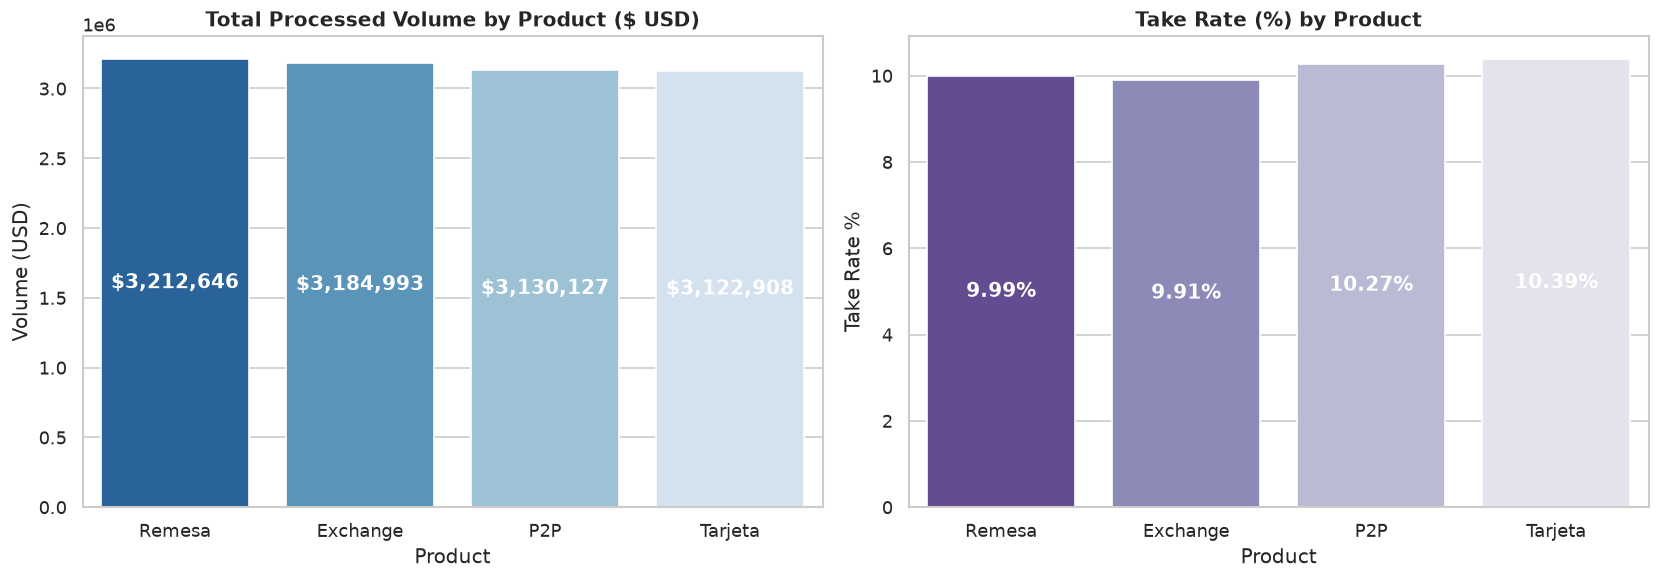

product,total_txns,volume_usd,revenue_usd,avg_ticket_usd,take_rate_pct
Remesa,1269,3212645.92,320834.55,2531.635871,9.986614
Exchange,1248,3184992.94,315528.20,2552.077676,9.906716
P2P,1236,3130126.65,321544.68,2532.464927,10.272577
Tarjeta,1247,3122908.18,324457.46,2504.336953,10.389593


In [6]:
# Aggregation by financial product
prod_summary = df_transactions.groupby('product').agg(
    total_txns=('transaction_id', 'count'),
    volume_usd=('origin_amount_usd', 'sum'),
    revenue_usd=('revenue', 'sum'),
    avg_ticket_usd=('origin_amount_usd', 'mean')
).reset_index()
prod_summary['take_rate_pct'] = (prod_summary['revenue_usd'] / prod_summary['volume_usd']) * 100
prod_summary = prod_summary.sort_values(by='volume_usd', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=prod_summary, x='product', y='volume_usd', ax=axes[0], palette='Blues_r')
axes[0].set_title('Total Processed Volume by Product ($ USD)', fontweight='bold')
axes[0].set_ylabel('Volume (USD)')

sns.barplot(data=prod_summary, x='product', y='take_rate_pct', ax=axes[1], palette='Purples_r')
axes[1].set_title('Take Rate (%) by Product', fontweight='bold')
axes[1].set_ylabel('Take Rate %')
plt.show()

prod_summary


---
## 🌐 4. Cross-Border Corridor Traffic (Origin ➔ Destiny)

Money transfer routes across Latin America (Argentina, Chile, Colombia, Mexico, Peru). 
We construct a matrix comparing origin and destination countries to reveal the most prominent cross-border corridors.


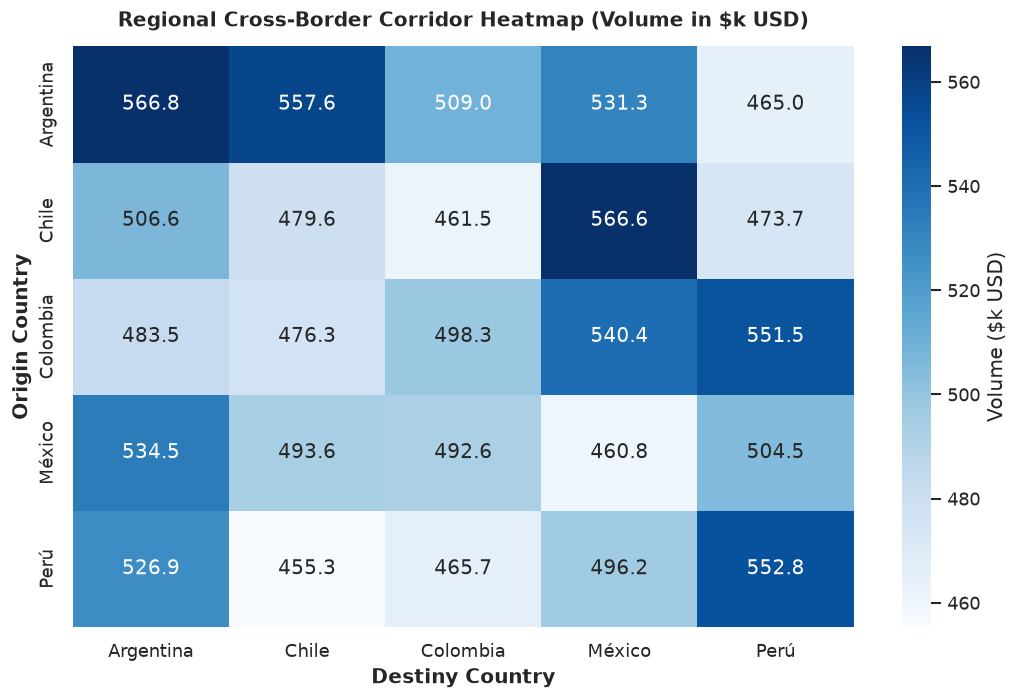

In [7]:
# Cross-border volume matrix
corridor_matrix = df_transactions.pivot_table(
    index='origin_country',
    columns='destiny_country',
    values='origin_amount_usd',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(9, 6))
sns.heatmap(corridor_matrix / 1e3, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Volume ($k USD)'})
plt.title('Regional Cross-Border Corridor Heatmap (Volume in $k USD)', fontweight='bold', pad=12)
plt.xlabel('Destiny Country', fontweight='bold')
plt.ylabel('Origin Country', fontweight='bold')
plt.show()


---
## 👥 5. Customer Segmentation & Inactivity Detection

In fintech auditing, keeping track of registered KYC customers who have **never performed a transaction** is essential for product activation campaigns.


In [8]:
# Detect customers with 0 transactions using SQL LEFT JOIN
inactive_query = """
SELECT 
    c.customer_id,
    c.name || ' ' || c.last_name AS customer_name,
    c.country AS customer_country,
    c.created_at AS registration_date
FROM customer c
LEFT JOIN "transaction" t ON c.customer_id = t.customer_id
WHERE t.transaction_id IS NULL
ORDER BY c.customer_id ASC;
"""
df_inactive = pd.read_sql(inactive_query, conn)
print(f"Total KYC Registered Customers: {len(df_customers)}")
print(f"Active Customers with ≥1 Txn: {df_transactions['customer_id'].nunique()}")
print(f"Inactive Customers (0 Txns): {len(df_inactive)} ({len(df_inactive)/len(df_customers)*100:.2f}%)")
df_inactive


Total KYC Registered Customers: 1000
Active Customers with ≥1 Txn: 989
Inactive Customers (0 Txns): 11 (1.10%)


customer_id,customer_name,customer_country,registration_date
245,Robert Lee,México,2024-09-03 09:02:35
251,Deborah Thompson,Argentina,2023-05-10 03:30:03
321,Savannah Mullins,Argentina,2023-07-15 04:07:09
418,Jason Davidson,Colombia,2023-10-09 21:07:45
469,Melissa Hill,Perú,2023-11-03 14:48:20
574,Natalie Hoffman,México,2025-01-15 18:09:37
636,Johnny Davis,Colombia,2024-05-27 03:43:05
670,Dawn Johnson,Chile,2024-08-23 04:28:29
778,Karen Schultz,Colombia,2024-02-27 12:40:41
908,Michael Atkins,Argentina,2023-04-17 08:35:36


---
## ⚡ 6. Relational SQL Analytics (ANSI SQL with CTEs & Window Functions)

Now let's execute the core analytical SQL queries directly on the SQLite database replica.


In [9]:
-- Top 3 customers with most transactions by product using DENSE_RANK()
q3_sql = """
WITH ranked_customers AS (
    SELECT 
        t.product,
        c.customer_id,
        c.name || ' ' || c.last_name AS customer_name,
        COUNT(t.transaction_id) AS transaction_count,
        ROUND(SUM(t.origin_amount_usd), 2) AS total_volume_usd,
        ROUND(SUM(t.revenue), 2) AS total_revenue_usd,
        DENSE_RANK() OVER (
            PARTITION BY t.product 
            ORDER BY COUNT(t.transaction_id) DESC
        ) AS ranking
    FROM "transaction" t
    JOIN customer c ON t.customer_id = c.customer_id
    GROUP BY t.product, c.customer_id, customer_name
)
SELECT 
    product,
    ranking,
    customer_id,
    customer_name,
    transaction_count,
    total_volume_usd,
    total_revenue_usd
FROM ranked_customers
WHERE ranking <= 3
ORDER BY product, ranking, transaction_count DESC;
"""
pd.read_sql(q3_sql, conn)


product,ranking,customer_id,customer_name,transaction_count,total_volume_usd,total_revenue_usd
Exchange,1,950,Laura Glenn,6,13341.83,1261.73
Exchange,2,88,Austin Adams,5,11879.18,1372.65
Exchange,2,301,Elizabeth Pierce,5,16351.18,593.94
Exchange,2,424,Kristen Hayes,5,12007.07,1840.50
Exchange,2,501,Nicholas Harris,5,13662.85,1585.46
Exchange,2,534,Mary Adams,5,10331.07,1775.98
Exchange,2,774,David Marshall,5,11277.34,1436.60
Exchange,2,851,Jeremy Baker,5,12280.91,1711.51
Exchange,2,905,Dawn Gray,5,11567.80,1228.81
Exchange,3,10,Stephen Clark,4,8642.51,1392.87


In [10]:
-- First transaction of each customer (Activation Cohort)
q4_sql = """
WITH first_txns AS (
    SELECT 
        customer_id,
        transaction_id,
        transaction_datetime,
        origin_amount_usd,
        product,
        origin_country,
        destiny_country,
        ROW_NUMBER() OVER (
            PARTITION BY customer_id 
            ORDER BY transaction_datetime ASC, transaction_id ASC
        ) AS rn
    FROM "transaction"
)
SELECT 
    customer_id,
    transaction_id,
    transaction_datetime,
    origin_amount_usd,
    product,
    origin_country || ' -> ' || destiny_country AS corridor
FROM first_txns
WHERE rn = 1
ORDER BY customer_id ASC
LIMIT 10;
"""
pd.read_sql(q4_sql, conn)


customer_id,transaction_id,transaction_datetime,origin_amount_usd,product,corridor
1,1338,2024-02-10 11:29:50,2470.05,Tarjeta,México -> Perú
2,1305,2024-03-19 21:25:02,983.40,Tarjeta,Chile -> Perú
3,2328,2024-01-28 11:44:38,2407.15,Tarjeta,México -> Chile
4,4690,2024-04-20 10:54:56,1787.62,Remesa,Chile -> Colombia
5,2444,2024-02-18 22:53:57,2120.07,P2P,Colombia -> México
6,3226,2024-02-13 09:51:01,3202.00,Tarjeta,Perú -> Perú
7,2303,2024-09-14 08:13:30,2271.91,Exchange,Chile -> Perú
8,3073,2024-03-14 23:56:35,2247.32,Remesa,Colombia -> Perú
9,2154,2024-08-02 01:00:47,1570.79,Tarjeta,Argentina -> Chile
10,2855,2024-01-30 03:44:20,622.70,Exchange,México -> México


---
## 💡 7. Strategic Conclusions & Business Insights

1. **Monetization Discipline:**
   - Over **$12.65M USD** was transacted, generating **$1.28M USD** in Gross Revenue with an average Take Rate of **10.14%**.
   - The Take Rate exhibited high stability between 9.57% (May 2024) and 11.21% (Nov 2024), demonstrating resilient pricing power across Latin America.

2. **Balanced Product Portfolio:**
   - Transaction volume is remarkably well-balanced across **Remesa (25.4%)**, **Exchange (25.2%)**, **Tarjeta (24.7%)**, and **P2P (24.7%)**.
   - This prevents over-reliance on a single revenue stream and protects against corridor-specific regulatory shifts.

3. **Regional Corridor Dynamics:**
   - Key trade and remittance hubs are led by corridors connecting **Peru, Mexico, Colombia, and Chile**.
   - Intracountry and bilateral corridor flows show steady recurring tickets averaging **~$2,530 USD**.

4. **Product Activation Opportunity:**
   - Out of 1,000 KYC customers, **989 are active** (98.9% activation rate) and only **11 customers** have 0 transactions.
   - Recommended action: Launch a targeted zero-fee onboarding promo for the 11 inactive accounts to achieve 100% portfolio activation.

---
*Generated as part of the Neobank Data Science & AI Project.*  
*To launch the interactive Copilot BI Web App, run `python serve.py` or double-click `run_dashboard.bat`.*
